# 08 · Tree detection boxes meet public height surfaces

Run pretrained DeepForest inference on a public 2022 Dutch orthophoto, attach AHN4 surface-height statistics, and export the results in a GeoPackage. CPU is supported; CUDA is recommended. There are no reference crown labels in this crop.

[Notebook index](README.md) · [Companion article](../docs/articles/tree-crowns-height-distance.md) · [Data sources and licences](../docs/DATA_SOURCES.md)

Run every cell from top to bottom in the locked Python 3.12 environment. The first run downloads the required public data pack and checks its SHA-256. Generated artifacts remain in the ignored `outputs/` directory.

In [1]:
import json
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython import get_ipython
from IPython.display import display

from geoai_portfolio.io import ensure_data, workspace

get_ipython().run_line_magic("matplotlib", "inline")
plt.rcParams.update(
    {
        "figure.dpi": 110,
        "figure.figsize": (10, 4),
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titleweight": "bold",
        "axes.labelsize": 9,
        "axes.titlesize": 11,
        "font.size": 10,
        "savefig.bbox": "tight",
    }
)
pd.set_option("display.precision", 4)

In [2]:
import rasterio

from geoai_portfolio.neural import device_name
from geoai_portfolio.rasters import map_array
from geoai_portfolio.trees import DEEPFOREST_REVISION, detect_boxes, height_surface, summarize_boxes

data = ensure_data("ahn")
out = workspace("08-trees")
provenance = json.loads((data / "provenance.json").read_text())
display(
    pd.DataFrame(
        {
            "property": ["LiDAR UTC interval", "Orthophoto", "Horizontal CRS", "Height datum"],
            "value": [
                str(provenance["gps_utc_ranges"]["trees"]),
                "2022 leaf-on; exact flight date unavailable",
                "EPSG:28992; metres",
                "NAP, EPSG:5709; metres",
            ],
        }
    )
)

,property,value
0,LiDAR UTC interval,"['2022-02-12T09:02:23.644402Z', '2022-02-12T09..."
1,Orthophoto,2022 leaf-on; exact flight date unavailable
2,Horizontal CRS,EPSG:28992; metres
3,Height datum,"NAP, EPSG:5709; metres"


## State the temporal and geometric limits first

The AHN4 observations in this Ede crop date to 12 February 2022. The 0.25 m RGB mosaic
is leaf-on 2022; it is not simultaneous. DTM and DSM use the same original AHN4 TOP tile
and 0.5 m weighted-IDW products. Both heights refer to NAP, so no vertical-datum
conversion is performed. The original LAS lacked a CRS record: the crop explicitly
assigns the provider-documented compound CRS, without moving coordinates.

DeepForest's public model was developed using other sites. Domain shift, season,
resolution and shadows can affect detections here. Boxes are not segmented crown
boundaries, and DSM minus DTM also contains buildings and other elevated objects.

In [3]:
device = device_name(os.environ.get("GEOAI_DEVICE", "auto"))
boxes = detect_boxes(data / "trees-rgb.tif", device=device, score_threshold=0.5)
height = height_surface(data / "trees-dsm.tif", data / "trees-dtm.tif")
summary = summarize_boxes(boxes, height, data / "trees-dtm.tif", min_valid=0.8)
print(
    {
        "device": device,
        "model_revision": DEEPFOREST_REVISION,
        "detections": len(boxes),
        "valid_height_fraction": height.count() / height.size,
        "negative_height_pixels": int((height < 0).sum()),
    }
)
display(summary[["label", "score", "valid_fraction", "valid_pixels", "surface_p95_m"]].head(12))

<checkout>\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


W0913 14:38:02.302000 45140 Lib\site-packages\torch\utils\flop_counter.py:113] triton not found; flop counting will not work for triton kernels


<checkout>\.venv\Lib\site-packages\torch\jit\_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


GPU available: True (cuda), used: True


TPU available: False, using: 0 TPU cores


💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


{'device': 'cuda', 'model_revision': 'cc21436bc5d572dde8ff5f93c1e71a32f563cace', 'detections': 25, 'valid_height_fraction': np.float64(0.9095878601074219), 'negative_height_pixels': 13}


,label,score,valid_fraction,valid_pixels,surface_p95_m
0,Tree,0.7499,0.9478,436,27.6821
1,Tree,0.6840,0.4833,203,NaN
2,Tree,0.6800,0.9205,405,26.7321
3,Tree,0.6457,1.0000,210,13.5787
4,Tree,0.6355,1.0000,110,21.0186
5,Tree,0.6248,0.9960,504,14.9268
6,Tree,0.6199,0.0000,0,NaN
7,Tree,0.6065,0.8708,209,16.8311
8,Tree,0.5894,0.7967,145,NaN
9,Tree,0.5859,0.8750,210,8.8660


## Inspect the map before interpreting a height

Inference uses 512-pixel windows with 64-pixel overlap; global NMS uses IoU 0.15.
The score threshold is 0.5. Scores are model outputs, not calibrated probabilities of
correctness. The 95th percentile summarizes valid 0.5 m surface pixels whose centres
lie inside each predicted box; coverage below 80% suppresses the height value. Negative
differences are reported, not silently clipped or replaced by zero.

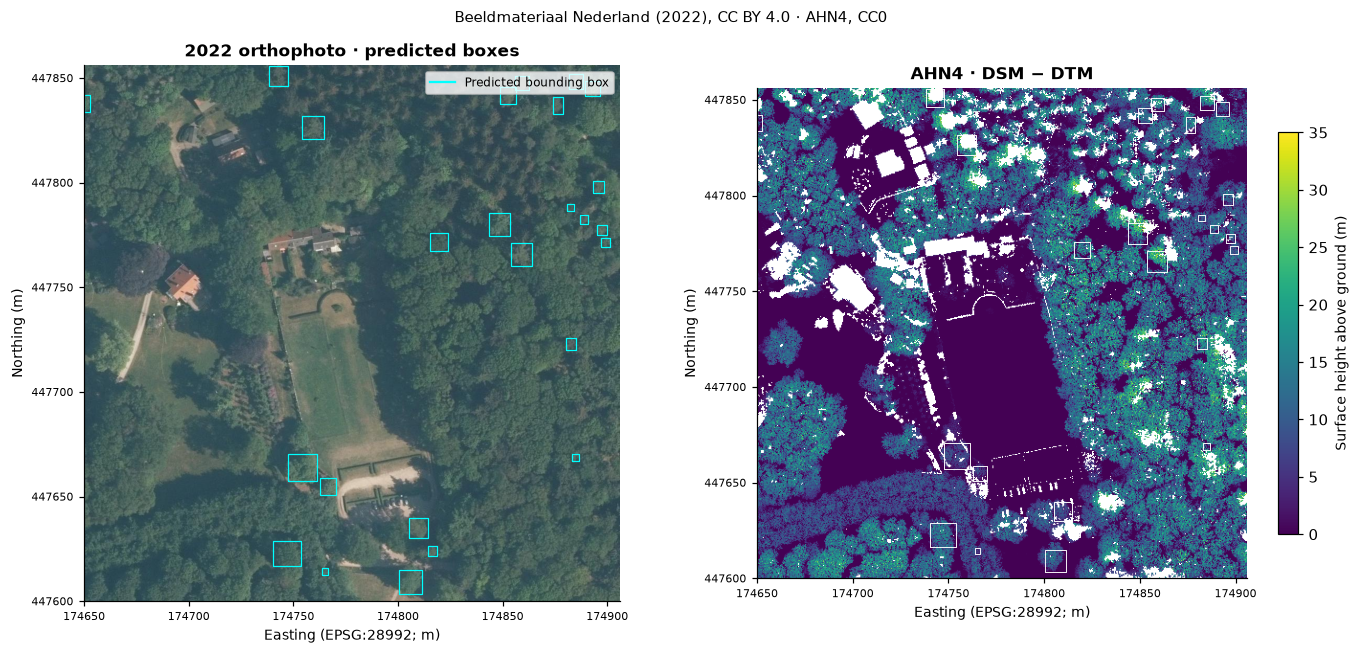

In [4]:
from matplotlib.lines import Line2D

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
with rasterio.open(data / "trees-rgb.tif") as source:
    rgb = source.read().transpose(1, 2, 0)
    map_array(axes[0], rgb, source, "2022 orthophoto · predicted boxes")
    boxes.boundary.plot(ax=axes[0], color="#00ffff", linewidth=0.8)
with rasterio.open(data / "trees-dtm.tif") as source:
    image = map_array(axes[1], height, source, "AHN4 · DSM − DTM", "viridis", 0, 35)
    boxes.boundary.plot(ax=axes[1], color="white", linewidth=0.6)
    fig.colorbar(image, ax=axes[1], label="Surface height above ground (m)", shrink=0.75)

axes[0].legend(
    handles=[Line2D([0], [0], color="#00ffff", label="Predicted bounding box")], fontsize=8
)
fig.suptitle("Beeldmateriaal Nederland (2022), CC BY 4.0 · AHN4, CC0", fontsize=10)
plt.tight_layout()
plt.show()

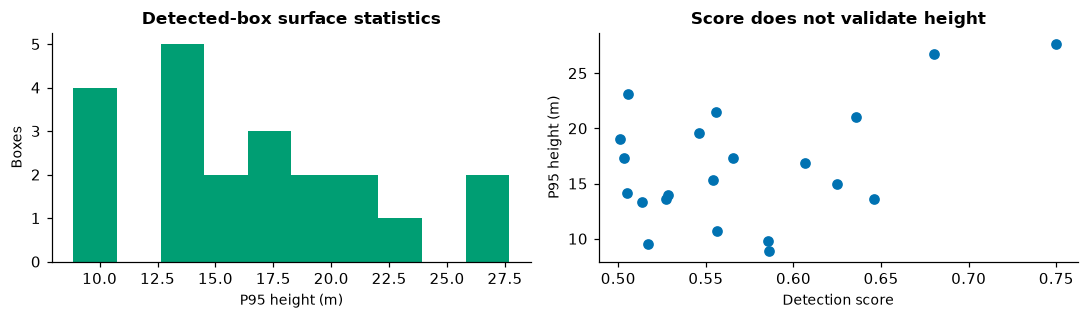

,surface_p95_m,nearest_box_center_m,valid_fraction
count,21.0000,25.0000,25.0000
mean,16.5686,21.2708,0.8712
std,5.3087,19.2001,0.2309
min,8.8660,6.2442,0.0000
25%,13.5787,8.8637,0.8708
50%,15.3397,15.3479,0.9571
75%,19.6071,20.1446,1.0000
max,27.6821,92.3795,1.0000


Exported tree-boxes.gpkg with predicted geometry and explicit height provenance.


In [5]:
from scipy.spatial import cKDTree

centers = np.column_stack([summary.geometry.centroid.x, summary.geometry.centroid.y])
if len(centers) > 1:
    summary["nearest_box_center_m"] = cKDTree(centers).query(centers, k=2)[0][:, 1]
else:
    summary["nearest_box_center_m"] = np.nan
summary["height_datum"] = "NAP EPSG:5709"
summary["height_role"] = "P95 surface inside detection box; not validated tree height"
summary.to_file(out / "tree-boxes.gpkg", layer="detections", driver="GPKG")
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].hist(summary.surface_p95_m.dropna(), bins=10, color="#009E73")
axes[0].set(title="Detected-box surface statistics", xlabel="P95 height (m)", ylabel="Boxes")
axes[1].scatter(summary.score, summary.surface_p95_m, color="#0072B2")
axes[1].set(
    title="Score does not validate height", xlabel="Detection score", ylabel="P95 height (m)"
)
plt.tight_layout()
plt.show()
display(summary[["surface_p95_m", "nearest_box_center_m", "valid_fraction"]].describe())
print("Exported tree-boxes.gpkg with predicted geometry and explicit height provenance.")

## What is still unknown

Field measurements or suitable same-season reference crowns are needed to validate
detection precision, recall and tree-height error. Nearest box-centre distance is a
two-dimensional geometric descriptor, not stem spacing or an infrastructure clearance.
The exported layer carries these distinctions so they survive beyond the notebook.

Sources: [DeepForest public model](https://huggingface.co/weecology/deepforest-tree),
[AHN products and vertical reference](https://www.ahn.nl/dataroom),
[Beeldmateriaal licences and acquisition seasons](https://www.beeldmateriaal.nl/dataroom).